# FleetSense Day 9 — Predictive Maintenance EDA: NASA C-MAPSS (FD001)

**Author:** Mohid Moneeb · **Project:** [FleetSense](https://github.com/MohidMoneeb/fleetsense-pipeline)

Predictive maintenance is the canonical industrial/automotive ML problem: *given a stream of
sensor readings from a machine, predict when it will fail so it can be serviced before it does.*
NASA's **C-MAPSS** turbofan dataset is its canonical public benchmark — a fleet of engines each
run to failure, with 21 sensors logged every cycle.

This notebook is an EDA of subset **FD001** (single operating condition, single fault mode). The
goal is to *understand the data before modeling*: what degrades, what's noise, and how the
prediction target is constructed.

### Three ways to frame the problem
- **RUL regression** — predict Remaining Useful Life (cycles left) as a continuous value. *The main framing used here.*
- **Anomaly detection** — flag readings that deviate from a healthy baseline, without labels.
- **Health-zone classification** — bucket each cycle into e.g. healthy / warning / critical.

FD001 structure: **100 engines**, each run to failure, **3 operational settings + 21 sensors** per cycle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

# Column names: unit, cycle, 3 settings, 21 sensors
index_names   = ["unit", "cycle"]
setting_names = ["setting_1", "setting_2", "setting_3"]
sensor_names  = [f"s_{i}" for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names

train = pd.read_csv("data/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
print("Shape:", train.shape)
train.head()

Shape: (20631, 26)


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 1. Dataset structure

Each row is one engine (`unit`) at one operating `cycle`. Engines are independent run-to-failure
trajectories — a fleet of the same engine type, each starting with slightly different wear.

In [2]:
n_engines = train["unit"].nunique()
cycles_per_engine = train.groupby("unit")["cycle"].max()
print(f"Engines: {n_engines}")
print(f"Total rows (cycles): {len(train)}")
print(f"Lifetime (cycles to failure) — min {cycles_per_engine.min()}, "
      f"max {cycles_per_engine.max()}, mean {cycles_per_engine.mean():.1f}")
print(f"Missing values: {int(train.isna().sum().sum())}")

Engines: 100
Total rows (cycles): 20631
Lifetime (cycles to failure) — min 128, max 362, mean 206.3
Missing values: 0


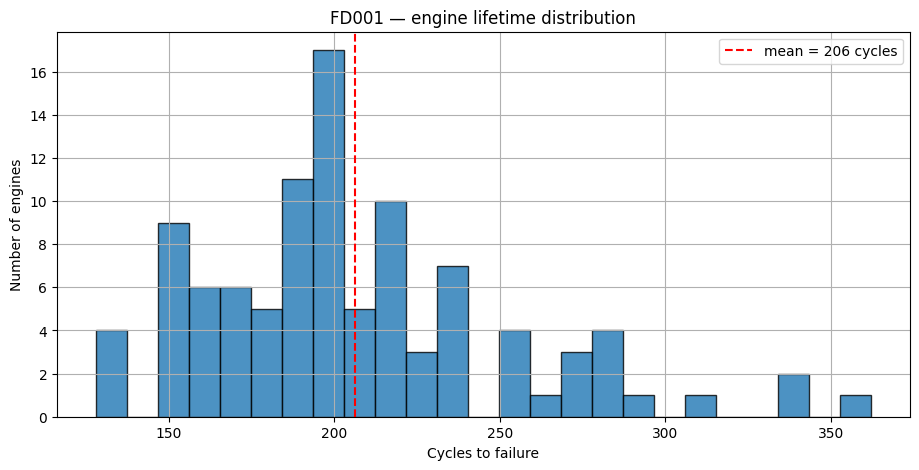

In [3]:
# Distribution of engine lifetimes
plt.figure()
plt.hist(cycles_per_engine, bins=25, edgecolor="black", alpha=0.8)
plt.axvline(cycles_per_engine.mean(), color="red", linestyle="--",
            label=f"mean = {cycles_per_engine.mean():.0f} cycles")
plt.xlabel("Cycles to failure"); plt.ylabel("Number of engines")
plt.title("FD001 — engine lifetime distribution"); plt.legend()
plt.show()

## 2. Which sensors actually carry a degradation signal?

Not every sensor is useful. Some are **flat** (constant — no information), some **degrade**
monotonically as the engine wears (the useful ones), and some are dominated by **noise**.
We separate them by standard deviation, then confirm visually.

In [4]:
# Standard deviation of each sensor across the whole dataset
sensor_std = train[sensor_names].std().sort_values()
flat_sensors = sensor_std[sensor_std < 1e-6].index.tolist()
print("FLAT / constant sensors (zero variance — drop these):")
print(" ", flat_sensors)
print()
print("Per-sensor standard deviation (ascending):")
sensor_std

FLAT / constant sensors (zero variance — drop these):
  ['s_1', 's_10', 's_19', 's_18', 's_16', 's_5']

Per-sensor standard deviation (ascending):


s_1     0.000000e+00
s_10    0.000000e+00
s_19    0.000000e+00
s_18    0.000000e+00
s_16    3.469531e-18
s_5     5.329200e-15
s_6     1.388985e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64

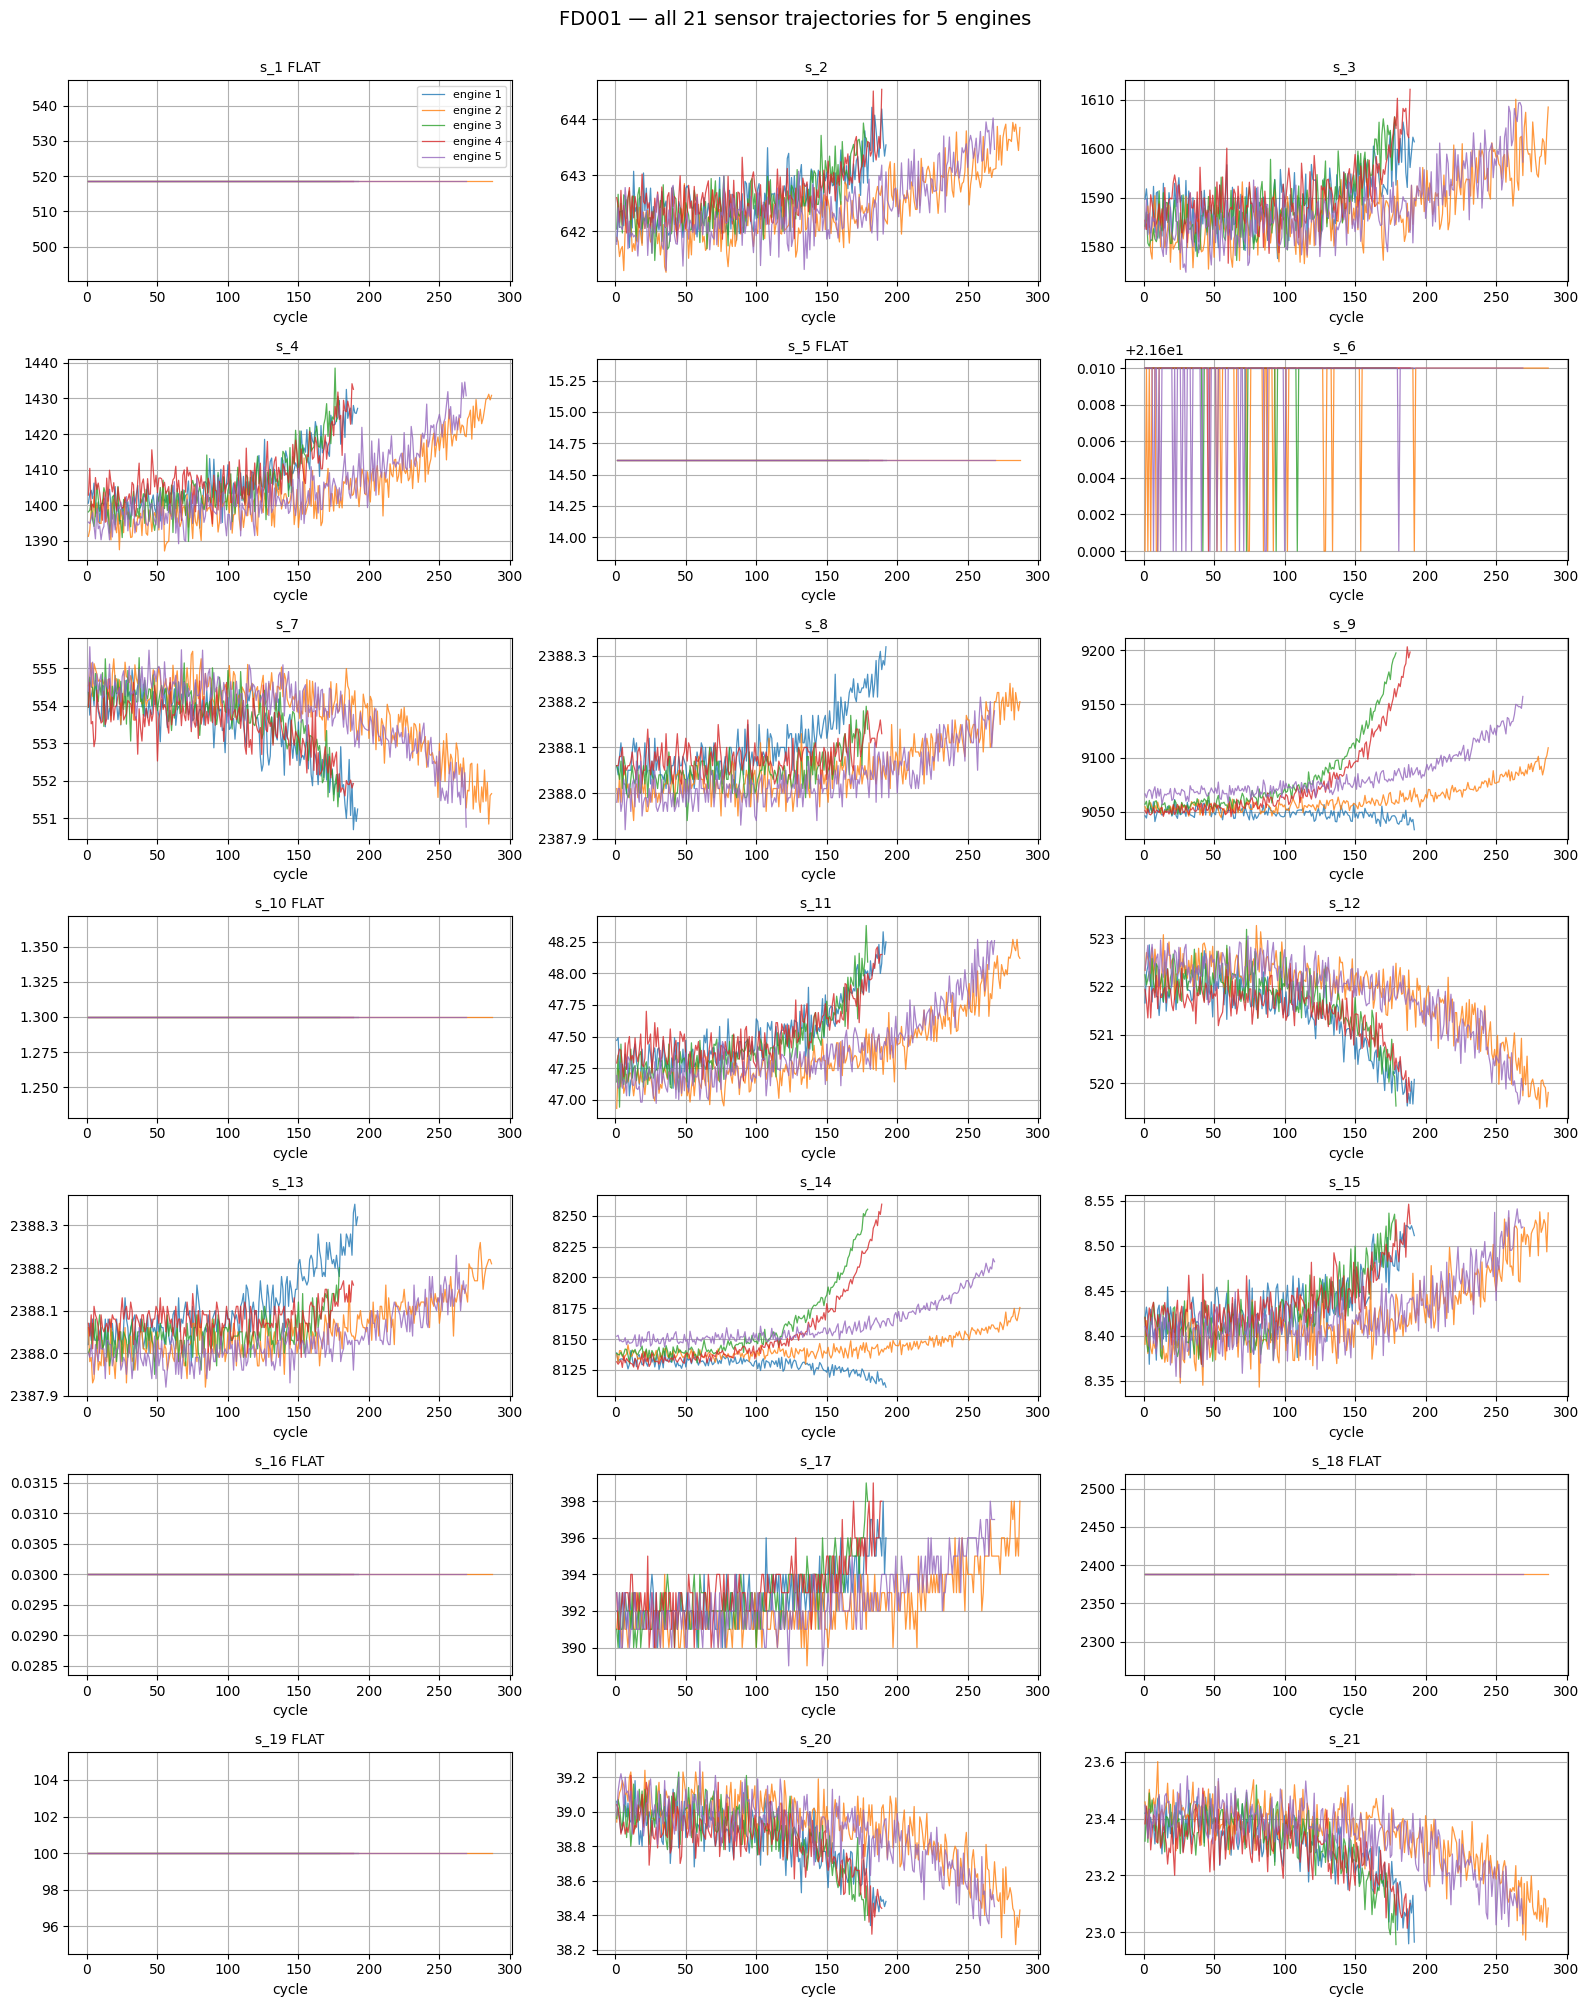

In [5]:
# Plot every sensor for 5 engines to see trajectories
sample_units = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(7, 3, figsize=(16, 20))
for ax, s in zip(axes.ravel(), sensor_names):
    for u in sample_units:
        d = train[train["unit"] == u]
        ax.plot(d["cycle"], d[s], linewidth=0.9, alpha=0.8, label=f"engine {u}")
    tag = "FLAT" if s in flat_sensors else ""
    ax.set_title(f"{s} {tag}", fontsize=10)
    ax.set_xlabel("cycle")
axes.ravel()[0].legend(fontsize=8, loc="best")
fig.suptitle("FD001 — all 21 sensor trajectories for 5 engines", y=1.001, fontsize=14)
plt.tight_layout(); plt.show()

### Reading the trajectories

- **Flat sensors** (`s_1, s_5, s_10, s_16, s_18, s_19`) have zero variance across the whole run —
  under FD001's single operating condition they never move, so they carry **no** degradation
  information and would be dropped before modeling. (`s_6` is *near*-constant — only rare discrete
  jumps — so it is similarly low-information.)
- **Degrading sensors** — the remaining channels (e.g. `s_2, s_3, s_4, s_7, s_11, s_12, s_15,
  s_17, s_20, s_21`) trend clearly upward or downward as cycles increase toward failure. These are the signal.
- The trends are **noisy but directional**: individual cycles jump around, yet the overall slope
  toward failure is unmistakable. That noise is why smoothing and windowing matter later.

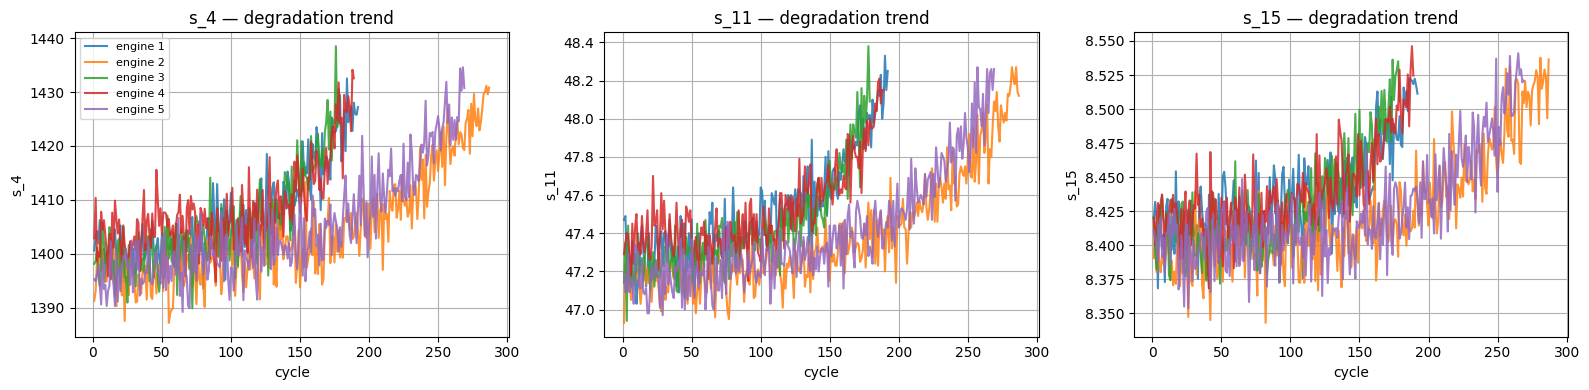

In [6]:
# Zoom in on 3 clearly-degrading sensors for the same 5 engines
degrading_examples = ["s_4", "s_11", "s_15"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, s in zip(axes, degrading_examples):
    for u in sample_units:
        d = train[train["unit"] == u]
        ax.plot(d["cycle"], d[s], alpha=0.85, label=f"engine {u}")
    ax.set_title(f"{s} — degradation trend"); ax.set_xlabel("cycle"); ax.set_ylabel(s)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Constructing the RUL label

The training data has no RUL column — we build it. For a run-to-failure trajectory, the engine
fails at its **last recorded cycle**, so:

$$\text{RUL} = \text{max cycle for that engine} - \text{current cycle}$$

At the final cycle RUL = 0 (failure); at the first cycle it equals the full lifetime.

In [7]:
def add_rul(df):
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df = df.copy()
    df["RUL"] = max_cycle - df["cycle"]
    return df

train = add_rul(train)
train[["unit", "cycle", "RUL"]].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


### Why clip RUL at ~125?

Early in an engine's life it is **healthy**, and the sensors look essentially identical whether
RUL is 250 or 200 — there is no degradation signal yet to distinguish them. Asking a model to
output a precise large RUL from a healthy-looking reading forces it to fit noise. **Clipping**
RUL to a ceiling (commonly 125) encodes a piecewise-linear assumption: *"healthy" until
degradation becomes visible, then linear decline.* This is the standard C-MAPSS convention and it
consistently improves RUL models. Below, the clip is visible as a flat top.

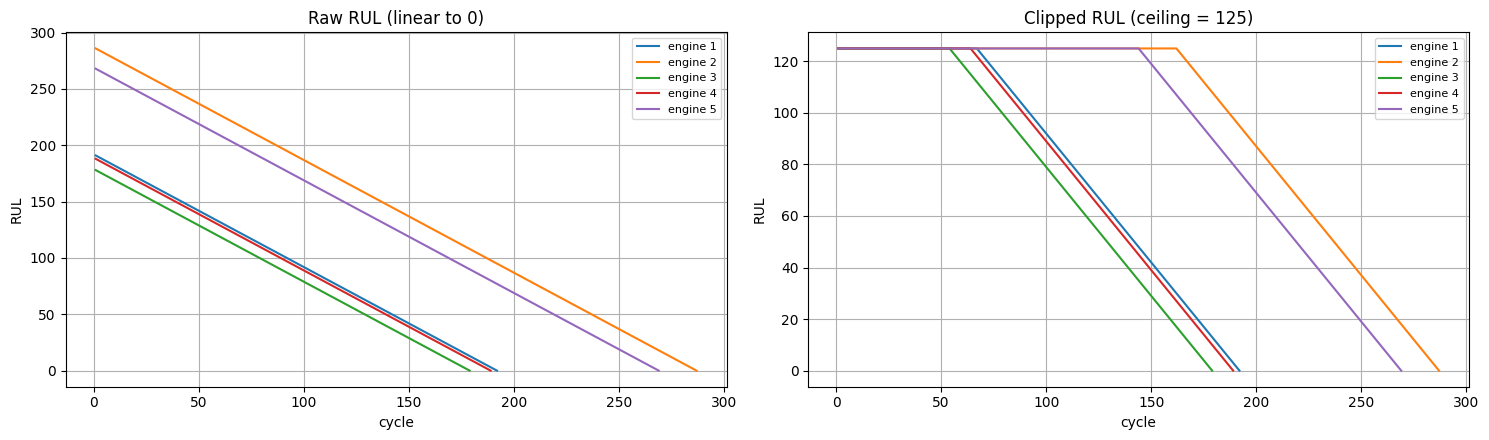

In [8]:
RUL_CLIP = 125
train["RUL_clipped"] = train["RUL"].clip(upper=RUL_CLIP)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for u in sample_units:
    d = train[train["unit"] == u]
    axes[0].plot(d["cycle"], d["RUL"], label=f"engine {u}")
    axes[1].plot(d["cycle"], d["RUL_clipped"], label=f"engine {u}")
axes[0].set_title("Raw RUL (linear to 0)")
axes[1].set_title(f"Clipped RUL (ceiling = {RUL_CLIP})")
for ax in axes:
    ax.set_xlabel("cycle"); ax.set_ylabel("RUL"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
# Sanity checks on the label
assert (train.groupby("unit")["RUL"].min() == 0).all(), "every engine should reach RUL=0"
print("RUL label checks passed.")
print(train[["RUL", "RUL_clipped"]].describe().round(1))

RUL label checks passed.
           RUL  RUL_clipped
count  20631.0      20631.0
mean     107.8         86.8
std       68.9         41.7
min        0.0          0.0
25%       51.0         51.0
50%      103.0        103.0
75%      155.0        125.0
max      361.0        125.0


## 4. FleetSense translation — turbofans → vehicles

The reason this dataset matters for FleetSense: predictive maintenance on a **fleet of turbofan
engines** is structurally the same problem as predictive maintenance on a **fleet of vehicles**.
The mapping is direct:

| C-MAPSS (turbofan) | FleetSense (vehicle) |
|---|---|
| Engine unit | Individual vehicle in the fleet |
| Operating cycle | A trip / drive |
| 21 engine sensors | OBD-II / CAN channels (coolant temp, RPM, battery voltage, …) |
| Run-to-failure trajectory | Vehicle telemetry from healthy through to a fault |
| RUL (cycles to failure) | Trips / miles until a component needs service |

FleetSense already ingests per-vehicle time-series telemetry keyed by `vehicle_id` and `timestamp`
— exactly the shape of C-MAPSS keyed by `unit` and `cycle`. The RUL-regression framing learned
here transfers straight onto that pipeline: same label construction, same clip, same "find the
degrading channels, drop the flat ones" EDA discipline.

## Summary
- FD001: 100 engines, 100–360 cycles each, 21 sensors + 3 settings, **no missing values**.
- 7 sensors are flat and information-free under the single operating condition; ~12 carry a clear degradation trend.
- RUL is built as `max_cycle − cycle` and clipped at 125 to avoid fitting noise in the healthy region.
- The problem maps cleanly onto vehicle predictive maintenance — the next FleetSense module.